In [1]:
import duckdb
import pandas as pd
import os
import json
from dotenv import load_dotenv

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")


In [2]:
def extrair_features_moodle(pasta_dados="export/", curso_id="10464"):
    """
    Varre os logs brutos do Moodle e consolida métricas comportamentais 
    por aluno usando processamento analítico do DuckDB.
    """
    
    query_features = f"""
        SELECT 
            username,
            -- 1. Features de Volume de Engajamento
            COUNT(*) AS total_cliques,
            
            -- Converte o timestamp Unix para Data e conta os dias distintos estudados
            COUNT(DISTINCT CAST(to_timestamp(CAST(timecreated AS BIGINT)) AS DATE)) AS dias_ativos,
            
            -- 2. Features Comportamentais (Ativo vs Passivo)
            SUM(CASE WHEN crud IN ('c', 'u') THEN 1 ELSE 0 END) AS interacoes_ativas,
            SUM(CASE WHEN crud = 'r' THEN 1 ELSE 0 END) AS interacoes_passivas,
            
            -- 3. Features de Foco em Componentes
            SUM(CASE WHEN component = 'mod_forum' THEN 1 ELSE 0 END) AS cliques_forum,
            SUM(CASE WHEN component = 'mod_quiz' THEN 1 ELSE 0 END) AS cliques_quiz,
            SUM(CASE WHEN component IN ('mod_resource', 'mod_book', 'mod_page') THEN 1 ELSE 0 END) AS cliques_materiais
            
        FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
        WHERE username NOT IN ('0', '-1', '', 'nan') 
          AND username IS NOT NULL
          AND courseid = '{curso_id}'
        GROUP BY username
        ORDER BY total_cliques DESC
    """
    
    # Executa a query e já devolve um DataFrame Pandas limpinho
    df_features = duckdb.query(query_features).df()
    return df_features

df = extrair_features_moodle()
print(df.head())

                  username  total_cliques  dias_ativos  interacoes_ativas  \
0  user6442803380426375169          31212           86             5250.0   
1  user8540069828419911681          24996           71            22080.0   
2  user7619359643386511361          17247           39             4721.0   
3  user7959886181284446209           7180           38              212.0   
4  user2959087468848087041           6685           36              679.0   

   interacoes_passivas  cliques_forum  cliques_quiz  cliques_materiais  
0              25806.0        18262.0         460.0             1376.0  
1               2892.0         1240.0          50.0              260.0  
2              12519.0        15427.0          33.0              182.0  
3               6965.0         5871.0         139.0              228.0  
4               6002.0         4658.0          37.0               77.0  


In [3]:
def extrair_notas_medias(pasta_dados="export/"):
    """
    Extrai a nota mais recente de cada item para cada aluno
    e calcula a nota média final (Target).
    """
    query_notas = f"""
        WITH NotasRecentes AS (
            SELECT 
                username,
                itemid,
                arg_max(CAST(finalgrade AS FLOAT), CAST(timemodified AS BIGINT)) AS nota_recente,
                arg_max(CAST(rawgrademax AS FLOAT), CAST(timemodified AS BIGINT)) AS nota_maxima
            FROM read_csv_auto('{pasta_dados}mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)
            WHERE finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL
              AND rawgrademax NOT IN ('', 'nan', 'None') AND rawgrademax IS NOT NULL
              AND username NOT IN ('0', '-1', '', 'nan')
            GROUP BY username, itemid
        ),
        NotasNormalizadas AS (
            -- Calcular a proporção (0 a 1) para cada atividade
            SELECT 
                username,
                itemid,
                CASE 
                    WHEN nota_maxima > 0 THEN nota_recente / nota_maxima 
                    ELSE 0.0 
                END AS nota_item_0_a_1
            FROM NotasRecentes
        )
        -- Calcular a média geral final do aluno
        SELECT 
            username,
            AVG(nota_item_0_a_1) AS nota_media
        FROM NotasNormalizadas
        GROUP BY username
        ORDER BY nota_media DESC
    """
    
    # Executa a query e retorna o DataFrame
    return duckdb.query(query_notas).df()

# Executa a função e guarda o DataFrame com o nosso "Target"
df_target = extrair_notas_medias()

# Exibe as primeiras linhas para validação
display(df_target.shape[0], "  alunos no target")

1202

'  alunos no target'

In [4]:
from functools import reduce

# 1. Configuração

load_dotenv()

export_path = os.getenv("PASTA_DADOS")

atividades_path = os.path.join(export_path, "atividades.json")
nivel_desordem_path = os.path.join(export_path, "nivel_desordem.json")
visualizacoes_por_objeto_path = os.path.join(export_path, "visualizacoes_por_objeto.json")
proporcao_visualizacoes_path = os.path.join(export_path, "proporcao_visualizacoes_por_atividade.json")
pontuacao_path = os.path.join(export_path, "pontuacao.json")
porcentagem_curso_path = os.path.join(export_path, "porcentagem_curso_acessada.json")
tentativas_por_questionario_path = os.path.join(export_path, "tentativas_por_questionario.json")
tempo_resposta_path = os.path.join(export_path, "tempo_resposta.json")
tempo_total_gasto_path = os.path.join(export_path, "tempo_total_gasto_em_visitas_reais.json")

# 2.1. Desordem por Sessão

with open(nivel_desordem_path, 'r', encoding='utf-8') as f:
    desordem_json = json.load(f)
dados_desordem = {}
for id_sessao, dados_sessao in desordem_json.get("Course 10464", {}).get("sessoes", {}).items():
    for username, valor in dados_sessao.get("nivel_desordem_por_usuario", {}).items():
        if username not in dados_desordem:
            dados_desordem[username] = {"username": username}
        dados_desordem[username][f"desordem_sessao_{id_sessao}"] = valor
df_desordem = pd.DataFrame(list(dados_desordem.values()))

# 2.2. Pontuação
with open(pontuacao_path, 'r', encoding='utf-8') as f:
    pont_data = json.load(f)
df_pontuacao = pd.DataFrame(pont_data)[['usuario', 'pontuacao']]
df_pontuacao = df_pontuacao.rename(columns={'usuario': 'username'}) # Padronizando a chave

# 2.3. Porcentagem do Curso Acessada (Desdobrando geral e sessões)
with open(porcentagem_curso_path, 'r', encoding='utf-8') as f:
    perc_json = json.load(f)
dados_perc = []
for username, dados_aluno in perc_json.get('Course 10464', {}).items():
    registro = {'username': username, 'porcentagem_geral': dados_aluno.get('geral', 0.0)}
    for id_sessao, valor_sessao in dados_aluno.get('sessoes', {}).items():
        registro[f'porcentagem_sessao_{id_sessao}'] = valor_sessao
    dados_perc.append(registro)
df_porcentagem = pd.DataFrame(dados_perc)

# 2.4. Tentativas por Questionário (Somando tudo por aluno)
with open(tentativas_por_questionario_path, 'r', encoding='utf-8') as f:
    tentativas_data = json.load(f)
df_tentativas = pd.DataFrame(tentativas_data)
df_tentativas = df_tentativas.groupby('usuario')['total_tentativas'].sum().reset_index()
df_tentativas = df_tentativas.rename(columns={'usuario': 'username', 'total_tentativas': 'soma_tentativas_quizzes'})

# 2.5. Tempo de Resposta (Transformando PT...S em segundos)
with open(tempo_resposta_path, 'r', encoding='utf-8') as f:
    tempo_resp_data = json.load(f)
df_tempo_resp = pd.DataFrame(tempo_resp_data)

# Regex para extrair D, H, M, S de um formato ISO 8601
regex_tempo = r'P(?:(\d+)D)?T(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
extraido_resp = df_tempo_resp['tempo_resposta'].str.extract(regex_tempo).fillna(0).astype(int)

# D*86400 + H*3600 + M*60 + S
df_tempo_resp['tempo_resp_segundos'] = (
    extraido_resp[0] * 86400 + 
    extraido_resp[1] * 3600 + 
    extraido_resp[2] * 60 + 
    extraido_resp[3]
)

# Tirando a média de tempo de resposta por aluno
df_tempo_resp = df_tempo_resp.groupby('usuario')['tempo_resp_segundos'].mean().reset_index()
df_tempo_resp = df_tempo_resp.rename(columns={'usuario': 'username', 'tempo_resp_segundos': 'media_tempo_resposta_seg'})


# ==========================================
# 2.6. Tempo Total Gasto na Plataforma
# ==========================================
with open(tempo_total_gasto_path, 'r', encoding='utf-8') as f:
    tempo_gasto_data = json.load(f)
df_tempo_gasto = pd.DataFrame(tempo_gasto_data)

# Aplicando a mesma extração Regex (O Moodle pode gerar números enormes como PT436985S aqui)
extraido_gasto = df_tempo_gasto['tempo_passado'].str.extract(regex_tempo).fillna(0).astype(int)

# Calculando Segundos
df_tempo_gasto['tempo_passado_seg'] = (
    extraido_gasto[0] * 86400 + 
    extraido_gasto[1] * 3600 + 
    extraido_gasto[2] * 60 + 
    extraido_gasto[3]
)

# Somando todo o tempo das visitas do aluno
df_tempo_gasto = df_tempo_gasto.groupby('usuario')['tempo_passado_seg'].sum().reset_index()
df_tempo_gasto = df_tempo_gasto.rename(columns={'usuario': 'username', 'tempo_passado_seg': 'tempo_total_ambiente_seg'})


# ==========================================
# 3. O GRANDE MERGE (Unindo tudo pelo Username)
# ==========================================
# Colocamos todos os DataFrames em uma lista
dataframes_para_unir = [
    df_desordem, 
    df_pontuacao, 
    df_porcentagem, 
    df_tentativas, 
    df_tempo_resp, 
    df_tempo_gasto,
    df
]

df_final = reduce(lambda left, right: pd.merge(left, right, on='username', how='outer'), dataframes_para_unir)

print(f"✅ Matriz de features construída com sucesso! Total de alunos: {len(df_final)}")
print(f"📊 Total de features (colunas) geradas: {len(df_final.columns)}")
print(f" Total de nulls por coluna:\n{df_final.isnull().sum()}")

df_final.to_csv(os.path.join(export_path, "matriz_comportamental.csv"), index=False)

✅ Matriz de features construída com sucesso! Total de alunos: 2168
📊 Total de features (colunas) geradas: 24
 Total de nulls por coluna:
username                       0
desordem_sessao_58964        134
desordem_sessao_58966        941
desordem_sessao_58965        160
desordem_sessao_58968       1031
desordem_sessao_58967       1177
pontuacao                    980
porcentagem_geral             27
porcentagem_sessao_58964      27
porcentagem_sessao_58966      27
porcentagem_sessao_58965      27
porcentagem_sessao_58968      27
porcentagem_sessao_58969      27
porcentagem_sessao_58967      27
soma_tentativas_quizzes      994
media_tempo_resposta_seg     824
tempo_total_ambiente_seg       0
total_cliques                  0
dias_ativos                    0
interacoes_ativas              0
interacoes_passivas            0
cliques_forum                  0
cliques_quiz                   0
cliques_materiais              0
dtype: int64


In [5]:
def aplicar_imputacao_simples(X, estrategia='median', valor_constante=0.0):
    print(f"Aplicando imputação: {estrategia}...")

    if estrategia == 'constant':
        imputer = SimpleImputer(
            strategy=estrategia,
            fill_value=valor_constante
        )
    else:
        imputer = SimpleImputer(strategy=estrategia)

    X_imputado = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )

    return X_imputado, imputer

In [6]:
def transformar_com_imputador(X, imputer):
    X_imputado = pd.DataFrame(
        imputer.transform(X),
        columns=X.columns,
        index=X.index
    )

    return X_imputado

In [7]:
def treinar_e_avaliar_rf(X_train, X_test, y_train, y_test):
    """Treina Random Forest e retorna métricas de classificação."""
    modelo_rf = RandomForestClassifier(
        n_estimators=200, 
        max_depth=5,
        random_state=42, 
        class_weight='balanced'
    )
    modelo_rf.fit(X_train, y_train)
    predicoes = modelo_rf.predict(X_test)
    
    acc = accuracy_score(y_test, predicoes)
    prec = precision_score(y_test, predicoes, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predicoes, average='weighted', zero_division=0)
    
    return modelo_rf, acc, prec, f1, predicoes

def treinar_e_avaliar_svm(X_train, X_test, y_train, y_test):
    """Treina SVM com Escalonamento embutido."""

    modelo_svm = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=1.0, random_state=42, class_weight='balanced')
    )
    modelo_svm.fit(X_train, y_train)
    predicoes = modelo_svm.predict(X_test)
    
    acc = accuracy_score(y_test, predicoes)
    prec = precision_score(y_test, predicoes, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predicoes, average='weighted', zero_division=0)
    
    return modelo_svm, acc, prec, f1, predicoes

🔄 Juntando matriz de features com o Target...

Distribuição dos alunos por categoria de desempenho:
classe_desempenho
1_Muito_Ruim     15
2_Ruim          104
3_Regular       160
4_Bom           185
5_Muito_Bom     738
Name: count, dtype: int64

🚀 Iniciando Treinamentos...
----------------------------------------
Testando imputação: MEAN...
Aplicando imputação: mean...
Testando imputação: MEDIAN...
Aplicando imputação: median...
Testando imputação: MOST_FREQUENT...
Aplicando imputação: most_frequent...
Testando imputação: CONSTANT...
Aplicando imputação: constant...

🏆 RANKING DE DESEMPENHO (Ordenado por F1-Score):


,Modelo,Imputacao,Acuracia,Precisao,F1-Score
0,Random Forest,mean,0.738589,0.782647,0.752668
2,Random Forest,median,0.738589,0.773335,0.750082
4,Random Forest,most_frequent,0.734440,0.763805,0.745051
6,Random Forest,constant,0.721992,0.755735,0.734347
5,SVM,most_frequent,0.705394,0.730825,0.711930
1,SVM,mean,0.705394,0.724645,0.709958
3,SVM,median,0.701245,0.721849,0.706617
7,SVM,constant,0.697095,0.722433,0.705381


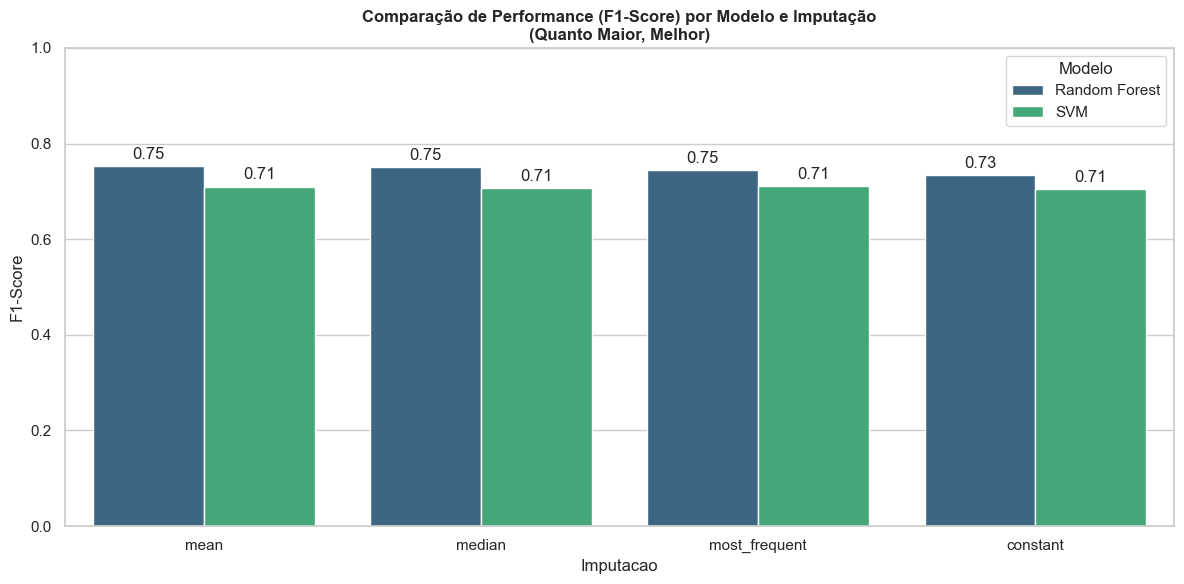


📊 Gerando Matriz de Confusão para a melhor configuração: Random Forest (mean)


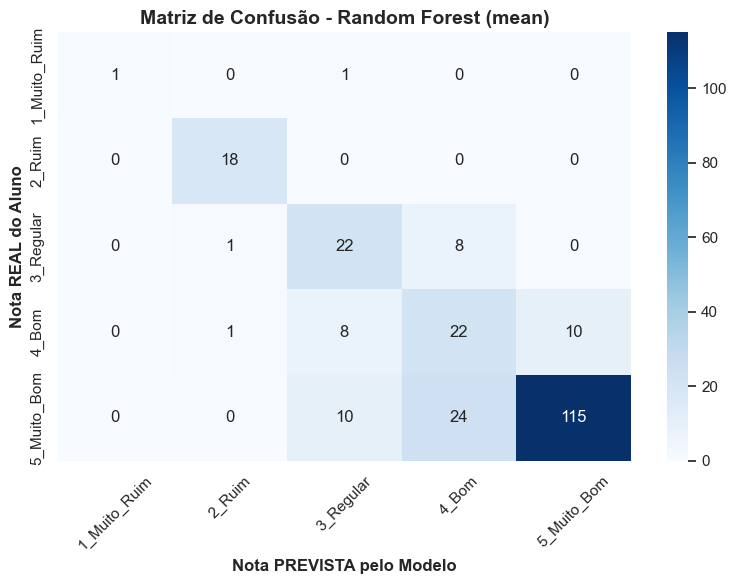

In [8]:
def executar_experimentos_classificacao(df_features, df_alvo, coluna_alvo='nota_media', random_state=42):
    print("🔄 Juntando matriz de features com o Target...")
    df_completo = pd.merge(df_features, df_alvo, on='username', how='left')

    #VERIFICAR ISSO AQUI
    #df_completo[coluna_alvo] = df_completo[coluna_alvo].fillna(0.0)
    
    limites = [-0.01, 0.2, 0.4, 0.6, 0.8, 1.0]
    rotulos = ['1_Muito_Ruim', '2_Ruim', '3_Regular', '4_Bom', '5_Muito_Bom']
    
    df_completo['classe_desempenho'] = pd.cut(df_completo[coluna_alvo], bins=limites, labels=rotulos)
    
    df_completo = df_completo.dropna(subset=['classe_desempenho'])
    
    print("\nDistribuição dos alunos por categoria de desempenho:")
    print(df_completo['classe_desempenho'].value_counts().sort_index())
    
    X = df_completo.drop(columns=['username', coluna_alvo, 'classe_desempenho'])
    y = df_completo['classe_desempenho']
    
    estrategias = ['mean', 'median', 'most_frequent', 'constant']
    resultados = []
    
    # Variáveis para rastrear o melhor modelo para a Matriz de Confusão
    melhor_f1 = 0
    melhor_config = ""
    melhores_predicoes = None
    y_test_final = None
    
    print("\n🚀 Iniciando Treinamentos...\n" + "-"*40)
    

    for est in estrategias:
        print(f"Testando imputação: {est.upper()}...")
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
        
        X_train, imputer = aplicar_imputacao_simples(
            X_train,
            estrategia=est,
            valor_constante=0.0
        )

        X_test = transformar_com_imputador(
            X_test,
            imputer
        )
        
        # --- Treino Random Forest ---
        _, acc_rf, prec_rf, f1_rf, preds_rf = treinar_e_avaliar_rf(X_train, X_test, y_train, y_test)
        resultados.append({'Modelo': 'Random Forest', 'Imputacao': est, 'Acuracia': acc_rf, 'Precisao': prec_rf, 'F1-Score': f1_rf})
        
        if f1_rf > melhor_f1:
            melhor_f1 = f1_rf; melhores_predicoes = preds_rf; y_test_final = y_test
            melhor_config = f"Random Forest ({est})"

        # --- Treino SVM ---
        _, acc_svm, prec_svm, f1_svm, preds_svm = treinar_e_avaliar_svm(X_train, X_test, y_train, y_test)
        resultados.append({'Modelo': 'SVM', 'Imputacao': est, 'Acuracia': acc_svm, 'Precisao': prec_svm, 'F1-Score': f1_svm})
        
        if f1_svm > melhor_f1:
            melhor_f1 = f1_svm; melhores_predicoes = preds_svm; y_test_final = y_test
            melhor_config = f"SVM ({est})"

    # 4. EXIBIÇÃO DE RESULTADOS GERAIS
    df_resultados = pd.DataFrame(resultados).sort_values(by='F1-Score', ascending=False)
    print("\n🏆 RANKING DE DESEMPENHO (Ordenado por F1-Score):")
    display(df_resultados)
    
    # 5. GRÁFICO COMPARATIVO DE ESTRATÉGIAS
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_resultados, x='Imputacao', y='F1-Score', hue='Modelo', palette='viridis')
    plt.title('Comparação de Performance (F1-Score) por Modelo e Imputação\n(Quanto Maior, Melhor)', fontweight='bold')
    plt.ylim(0, 1.0)
    plt.legend(title='Modelo')
    
    for i in ax.containers:
        ax.bar_label(i, fmt='%.2f', label_type='edge', padding=3)
    plt.tight_layout()
    plt.show()

    # 6. MATRIZ DE CONFUSÃO DO MELHOR MODELO
    print(f"\n📊 Gerando Matriz de Confusão para a melhor configuração: {melhor_config}")
    cm = confusion_matrix(y_test_final, melhores_predicoes, labels=rotulos)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rotulos, yticklabels=rotulos)
    plt.title(f'Matriz de Confusão - {melhor_config}', fontweight='bold', fontsize=14)
    plt.ylabel('Nota REAL do Aluno', fontsize=12, fontweight='bold')
    plt.xlabel('Nota PREVISTA pelo Modelo', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

executar_experimentos_classificacao(df_final, df_target, random_state=42)

# TODO: FAZER A NOTA DE ACORDO COM O TOTAL MAXIMO QUE ALUNO PODE TER DE NOTA.
# TODO: NOTA MÉDIA ERRADA